### Step -1 Data Ingestion
Data ingestion is the process of collecting and importing data from various sources into a storage system or database for further analysis and processing. It involves extracting data from different sources, transforming it into a suitable format, and loading it into a target system. Data ingestion can be performed in real-time or in batches, depending on the requirements of the application. 

We will use 3 methods:
1. Text based document loader
2. Web based loader
3. PDF based loader

In [3]:
# 1. Text Based Document Loaders
from langchain_community.document_loaders import TextLoader
loader = TextLoader("speech.txt")
text_documents=loader.load() 
text_documents

[Document(metadata={'source': 'speech.txt'}, page_content='Speech: The Power of Entertainment\nLadies and Gentlemen,\nToday, I want to talk about something we all consume, yet rarely stop to analyze: Entertainment. \nWhat is entertainment? It is often defined as an amusement or a performance, but it is so much more. Derived from the old French word entretenir, it literally means to "hold together" or support. It is the force that connects us—whether it is laughing together at a comedy show, cheering for a team, or being captivated by a movie. \nIn our fast-paced, modern world, filled with stress and, at times, monotony, entertainment is our sanctuary. It is not just about passing time; it is a vital escape that helps us pause, breathe, and rejuvenate. From literature and sports to digital media and music, entertainment takes many forms, but its purpose is singular: to bring happiness and lessen our worries. \nFurthermore, entertainment plays a crucial role in shaping our culture and so

In [1]:
# importing environment variables

import os 
from dotenv import load_dotenv

load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY") or ""

#-----------------------------------------------------------------------------------
# importing Ollama LLM : Mistral

from langchain_community.llms import Ollama
from langchain_ollama import OllamaLLM

llm=Ollama(model="mistral")

C:\Users\Anshul\AppData\Local\Temp\ipykernel_15864\3323229751.py:17: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm=Ollama(model="mistral")


In [2]:
# 2. Web based loader 

from langchain_community.document_loaders import WebBaseLoader
import bs4

# load, chunk and index the content of the HTML page

loader=WebBaseLoader(web_path=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
                     bs_kwargs=dict(parse_only=bs4.SoupStrainer(
                         class_=("post-title","post-content", "post-header") 
                     
                     )))

# classes present in the webpage HTML structure are post-title, post-content, post-header

text_documents=loader.load()

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
text_documents

[Document(metadata={'source': 'speech.txt'}, page_content='Speech: The Power of Entertainment\nLadies and Gentlemen,\nToday, I want to talk about something we all consume, yet rarely stop to analyze: Entertainment. \nWhat is entertainment? It is often defined as an amusement or a performance, but it is so much more. Derived from the old French word entretenir, it literally means to "hold together" or support. It is the force that connects us—whether it is laughing together at a comedy show, cheering for a team, or being captivated by a movie. \nIn our fast-paced, modern world, filled with stress and, at times, monotony, entertainment is our sanctuary. It is not just about passing time; it is a vital escape that helps us pause, breathe, and rejuvenate. From literature and sports to digital media and music, entertainment takes many forms, but its purpose is singular: to bring happiness and lessen our worries. \nFurthermore, entertainment plays a crucial role in shaping our culture and so

In [5]:
# 3. PDF based loader
from langchain_community.document_loaders import PyPDFLoader
loader=PyPDFLoader("attention-is-all-you-need-Paper.pdf")
docs=loader.load()


In [6]:
docs

[Document(metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On 

### Step 2: Text splitting  
Text splitting is the process of breaking down large pieces of text into smaller, more manageable chunks. This is often done to improve the efficiency of natural language processing (NLP) tasks, such as text classification, sentiment analysis, or language modeling. By splitting text into smaller segments, it becomes easier for algorithms to analyze and understand the content, leading to better performance and more accurate results.



In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
documents=text_splitter.split_documents(docs)
documents[:5]


[Document(metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On 

In [8]:
documents

[Document(metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On 

### Step 3: Create embeddings and store in vector database   
Embeddings are a way to represent words, phrases, or even entire documents as dense vectors in a continuous vector space. These vectors capture the semantic meaning of the text, allowing for more effective analysis and comparison. 

We will use 3 different vector databases:
1. ChromaDB
2. Faiss
3. 

In [11]:
# Vector Embedding and vector Store
# from langchain_community.embeddings import OllamaEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import Chroma
emb = OllamaEmbeddings(model="mistral")
db = Chroma.from_documents(documents[:5], emb)

In [13]:
query="who is the author for the paper?"
result=db.similarity_search(query)
result[0].page_content

'efﬁcient inference and visualizations. Lukasz and Aidan spent countless long days designing various parts of and\nimplementing tensor2tensor, replacing our earlier codebase, greatly improving results and massively accelerating\nour research.\n†Work performed while at Google Brain.\n‡Work performed while at Google Research.\n31st Conference on Neural Information Processing Systems (NIPS 2017), Long Beach, CA, USA.'

In [14]:
query="what is attention?"
result=db.similarity_search(query)
result[0].page_content

'efﬁcient inference and visualizations. Lukasz and Aidan spent countless long days designing various parts of and\nimplementing tensor2tensor, replacing our earlier codebase, greatly improving results and massively accelerating\nour research.\n†Work performed while at Google Brain.\n‡Work performed while at Google Research.\n31st Conference on Neural Information Processing Systems (NIPS 2017), Long Beach, CA, USA.'

In [1]:
## FAISS Vector Database
from langchain_community.vectorstores import FAISS
emb = OllamaEmbeddings(model="mistral")
db = FAISS.from_documents(documents[:2], emb)

NameError: name 'OllamaEmbeddings' is not defined

### Retrieval Augmented Generation (RAG) 
RAG is a technique in natural language processing that combines retrieval-based methods with generative models to enhance the quality and relevance of generated text. RAG works by first retrieving relevant information from a large corpus of documents based on a given query, and then using that retrieved information to generate a more informed and contextually accurate response. This approach allows for more accurate and informative responses, as the generative model can leverage the retrieved information to produce better outputs.

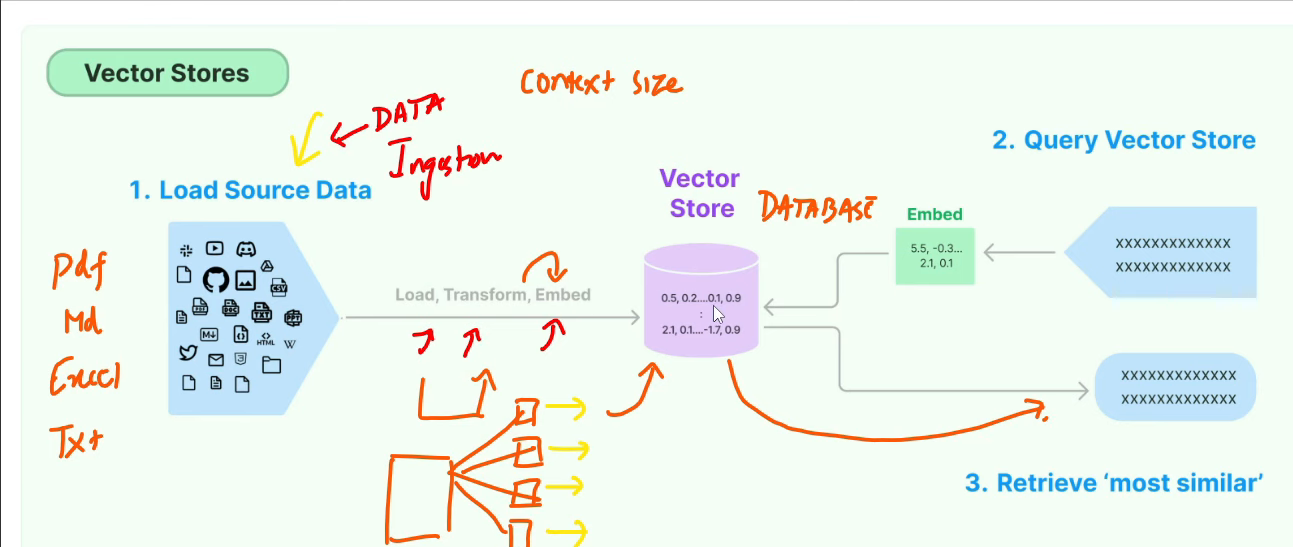